In [ ]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm
import ta

# ========================
# CONFIGURATION
# ========================
TICKERS = [
    "AAPL", "MSFT", "GOOG", "AMZN", "NVDA", "META", "SPY", "QQQ", "TLT",
    "XLE", "XLK", "XLF", "GLD", "SLV", "EEM", "EFA", "VNQ"
]

START = "2010-01-01"
END = "2025-01-01"
OUT_PATH = "processed/dataset_market.csv"
FRED_API_KEY = "191eddb37186cafc7627f77159ed8323"  # optional if you want macro vars

# ========================
# 1️⃣ TÉLÉCHARGEMENT DES PRIX
# ========================
def download_prices(tickers, start, end):
    all_data = {}
    for t in tqdm(tickers, desc="Téléchargement des prix"):
        try:
            df = yf.download(t, start=start, end=end, progress=False)[["Close", "Volume"]]
            df.columns = [f"{t}_Close", f"{t}_Volume"]
            all_data[t] = df
        except Exception as e:
            print(f"⚠️ Erreur pour {t}: {e}")
    data = pd.concat(all_data.values(), axis=1, join="outer")
    return data.ffill().bfill()

# ========================
# 2️⃣ FEATURES TECHNIQUES
# ========================
def compute_features(prices):
    feats = []
    tickers = sorted({col.split("_")[0] for col in prices.columns})
    for t in tqdm(tickers, desc="Calcul des features"):
        close = prices[f"{t}_Close"]
        vol = prices[f"{t}_Volume"]

        df = pd.DataFrame(index=close.index)
        df["ticker"] = t
        df["log_ret_1d"] = np.log(close / close.shift(1))
        df["log_ret_5d"] = np.log(close / close.shift(5))
        df["log_ret_20d"] = np.log(close / close.shift(20))

        df["vol_20d"] = df["log_ret_1d"].rolling(20).std()
        df["vol_ratio"] = (
            df["log_ret_1d"].rolling(5).std() / df["log_ret_1d"].rolling(20).std()
        )
        df["momentum_60d"] = close / close.shift(60) - 1
        df["momentum_120d"] = close / close.shift(120) - 1
        df["rsi_14d"] = ta.momentum.RSIIndicator(close, window=14).rsi()
        df["skew_60d"] = df["log_ret_1d"].rolling(60).skew()
        df["kurt_60d"] = df["log_ret_1d"].rolling(60).kurt()

        df["vol_turnover"] = vol / vol.rolling(20).mean()
        feats.append(df)
    feats = pd.concat(feats)
    feats = feats.reset_index().rename(columns={"index": "date"})
    return feats.dropna()

# ========================
# 3️⃣ RELATIONS INTER-ACTIFS
# ========================
def add_relational_features(feats, ref_ticker="SPY"):
    spy = feats[feats["ticker"] == ref_ticker][["Date", "log_ret_1d"]].rename(
        columns={"log_ret_1d": "spy_ret"}
    )
    merged = feats.merge(spy, on="Date", how="left")

    merged["corr_spy"] = (
        merged.groupby("ticker")
        .apply(lambda g: g["log_ret_1d"].rolling(60).corr(g["spy_ret"]))
        .reset_index(level=0, drop=True)
    )

    # Beta vs SPY
    def rolling_beta(x, y, window=60):
        cov = x.rolling(window).cov(y)
        var = y.rolling(window).var()
        return cov / var

    merged["beta_spy"] = (
        merged.groupby("ticker")
        .apply(lambda g: rolling_beta(g["log_ret_1d"], g["spy_ret"]))
        .reset_index(level=0, drop=True)
    )
    return merged
from fredapi import Fred

def download_macro(start, end, api_key=None):
    fred = Fred(api_key=api_key) if api_key else None
    macros = {}
    macro_series = {
        "DGS10": "DGS10",          # 10Y Yield
        "FEDFUNDS": "FEDFUNDS",    # Fed Funds
        "CPIAUCSL": "CPIAUCSL",    # CPI
        "UNRATE": "UNRATE",        # Unemployment rate
        "VIXCLS": "VIXCLS",        # VIX
        "DEXUSAL": "DEXUSAL",      # USD Index
        "TEDSPREAD": "TEDRATE",                    # Spread interbancaire
        "BAA10YM": "BAA10Y",                       # Corporate BBB Spread
        "STLFSI2": "STLFSI2",                      # Financial Stress Index
        "WALCL": "WALCL",                          # Fed Balance Sheet (Liquidité)
        "M2SL": "M2SL",                            # Masse monétaire M2
        "PMI": "NAPM",                   # Manufacturing PMI (ISM)
        "PMISERV": "NAPMSRVY",           # Services PMI
        "INDPRO": "INDPRO",              # Industrial Production
        "RETAIL": "RSXFS",               # Retail Sales ex autos
        "BDIY": "BDIY",                  # Baltic Dry Index
        "PALLFNFINDEXM": "PALLFNFINDEXM",# Commodity Index (CRB Proxy)
        "PUTCALL": "PUTCALL",   # CBOE Put/Call ratio
        "AAIISENT": "AAII",     # AAII Sentiment
        "CO2": "CO2",              # NOAA CO2 ppm
        "CRB": "PALLFNFINDEXM",    # Commodities index
        "OILINV": "PET.W_EPC0_SAX_YCUOK_MBBLD.A",  # EIA crude oil stocks
        "EMBIG": "EMBIG",          # Emerging market spread
        "DXY": "DTWEXBGS",         # USD index (si pas déjà)
}

    for code, name in macro_series.items():
        try:
            series = fred.get_series(name, observation_start=start, observation_end=end)
            macros[code] = series
        except Exception as e:
            print(f"⚠️ Erreur macro {code}: {e}")
    df_macro = pd.DataFrame(macros)
    df_macro.index = pd.to_datetime(df_macro.index)
    df_macro = df_macro.resample("B").ffill().fillna(method="ffill")
    df_macro["yield_spread"] = df_macro["DGS10"] - df_macro["FEDFUNDS"]
    df_macro["real_rate"] = df_macro["DGS10"] - df_macro["CPIAUCSL"].pct_change(12)
    return df_macro.reset_index().rename(columns={"index": "Date"})
def merge_macro(feats, macro):
    merged = feats.merge(macro, on="Date", how="left")
    merged = merged.fillna(method="ffill")
    return merged


# ========================
# MAIN PIPELINE
# ========================
if __name__ == "__main__":
    os.makedirs("processed", exist_ok=True)
    prices = download_prices(TICKERS, START, END)
    feats = compute_features(prices)
    feats = add_relational_features(feats, ref_ticker="SPY")

    macro = download_macro(START, END, api_key=FRED_API_KEY)
    final = merge_macro(feats, macro)
    
    final.to_csv(OUT_PATH)
    print(f"✅ Dataset enrichi sauvegardé : {OUT_PATH}")
    print(final.head())


Téléchargement des prix:   0%|          | 0/17 [00:00<?, ?it/s]C:\Users\romai\AppData\Local\Temp\ipykernel_4664\2830240281.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start, end=end, progress=False)[["Close", "Volume"]]
Téléchargement des prix:   6%|▌         | 1/17 [00:01<00:25,  1.58s/it]C:\Users\romai\AppData\Local\Temp\ipykernel_4664\2830240281.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start, end=end, progress=False)[["Close", "Volume"]]
Téléchargement des prix:  12%|█▏        | 2/17 [00:02<00:16,  1.11s/it]C:\Users\romai\AppData\Local\Temp\ipykernel_4664\2830240281.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start, end=end, progress=False)[["Close", "Volume"]]
Téléchargement des prix:  18%|█▊        | 3/17 [00:02<00:12,  1.12it/s]C:\Users\romai\AppData\Local\Temp\ipykernel_46

⚠️ Erreur macro PMI: Bad Request.  The series does not exist.
⚠️ Erreur macro PMISERV: Bad Request.  The series does not exist.
⚠️ Erreur macro BDIY: Bad Request.  The series does not exist.
⚠️ Erreur macro PUTCALL: Bad Request.  The series does not exist.
⚠️ Erreur macro AAIISENT: Bad Request.  The series does not exist.
⚠️ Erreur macro CO2: Bad Request.  The series does not exist.
⚠️ Erreur macro OILINV: Bad Request.  Invalid value for variable series_id.  Series IDs should be 25 or less alphanumeric characters.
⚠️ Erreur macro EMBIG: Bad Request.  The series does not exist.


C:\Users\romai\AppData\Local\Temp\ipykernel_4664\2830240281.py:135: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_macro = df_macro.resample("B").ffill().fillna(method="ffill")
C:\Users\romai\AppData\Local\Temp\ipykernel_4664\2830240281.py:141: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged = merged.fillna(method="ffill")


✅ Dataset enrichi sauvegardé : processed/dataset_market.csv
        Date ticker  log_ret_1d  log_ret_5d  log_ret_20d   vol_20d  vol_ratio  \
0 2010-06-25   AAPL   -0.008587   -0.027259     0.051352  0.017074   0.640637   
1 2010-06-28   AAPL    0.005982   -0.006945     0.043497  0.016890   0.626508   
2 2010-06-29   AAPL   -0.046265   -0.066739    -0.018028  0.019744   0.988686   
3 2010-06-30   AAPL   -0.018278   -0.074445    -0.048197  0.019867   0.984074   
4 2010-07-01   AAPL   -0.012200   -0.079349    -0.057248  0.019987   0.960312   

   momentum_60d  momentum_120d    rsi_14d  ...  STLFSI2      WALCL    M2SL  \
0      0.134893       0.246203  56.042509  ...   0.4202  2344497.0  8628.1   
1      0.137010       0.251517  57.370953  ...   0.4202  2344497.0  8628.1   
2      0.074133       0.214248  46.017384  ...   0.4202  2344497.0  8628.1   
3      0.050055       0.194463  42.548815  ...   0.4202  2330851.0  8628.1   
4      0.032751       0.172186  40.393371  ...   0.4202  233085

In [1]:
import pandas as pd
df =pd.read_csv("processed/dataset_market.csv")
df

,Unnamed: 0,Date,ticker,log_ret_1d,log_ret_5d,log_ret_20d,vol_20d,vol_ratio,momentum_60d,momentum_120d,...,STLFSI2,WALCL,M2SL,INDPRO,RETAIL,PALLFNFINDEXM,CRB,DXY,yield_spread,real_rate
0,0,2010-06-25,AAPL,-0.008587,-0.027259,0.051352,0.017074,0.640637,0.134893,0.246203,...,0.4202,2344497.0,8628.1,91.9033,308588.0,137.719024,137.719024,95.4582,2.94,3.120000
1,1,2010-06-28,AAPL,0.005982,-0.006945,0.043497,0.016890,0.626508,0.137010,0.251517,...,0.4202,2344497.0,8628.1,91.9033,308588.0,137.719024,137.719024,95.2696,2.87,3.050000
2,2,2010-06-29,AAPL,-0.046265,-0.066739,-0.018028,0.019744,0.988686,0.074133,0.214248,...,0.4202,2344497.0,8628.1,91.9033,308588.0,137.719024,137.719024,96.0199,2.79,2.970000
3,3,2010-06-30,AAPL,-0.018278,-0.074445,-0.048197,0.019867,0.984074,0.050055,0.194463,...,0.4202,2330851.0,8628.1,91.9033,308588.0,137.719024,137.719024,95.9934,2.79,2.970000
4,4,2010-07-01,AAPL,-0.012200,-0.079349,-0.057248,0.019987,0.960312,0.032751,0.172186,...,0.4202,2330851.0,8639.5,92.2549,309543.0,137.843341,137.843341,95.8018,2.78,2.958131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61633,61633,2024-12-24,XLK,0.010280,0.003926,0.030915,0.012275,1.582398,0.067169,0.036400,...,-0.8509,6889332.0,21407.9,101.9503,616833.0,166.207253,166.207253,128.5651,-0.05,4.590000
61634,61634,2024-12-26,XLK,0.000665,0.037376,0.026583,0.012249,0.513848,0.094545,0.030057,...,-0.8509,6885963.0,21407.9,101.9503,616833.0,166.207253,166.207253,128.5679,-0.06,4.580000
61635,61635,2024-12-27,XLK,-0.013384,0.022915,0.026837,0.012233,0.923792,0.072059,0.017186,...,-0.8509,6885963.0,21407.9,101.9503,616833.0,166.207253,166.207253,128.6972,-0.02,4.620000
61636,61636,2024-12-30,XLK,-0.012798,-0.004697,0.004798,0.012474,0.944910,0.054056,-0.010114,...,-0.8509,6885963.0,21407.9,101.9503,616833.0,166.207253,166.207253,129.0474,-0.09,4.550000


In [2]:
df.describe()

,Unnamed: 0,log_ret_1d,log_ret_5d,log_ret_20d,vol_20d,vol_ratio,momentum_60d,momentum_120d,rsi_14d,skew_60d,...,STLFSI2,WALCL,M2SL,INDPRO,RETAIL,PALLFNFINDEXM,CRB,DXY,yield_spread,real_rate
count,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,...,61638.000000,6.163800e+04,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000
mean,30818.500000,0.000576,0.002867,0.011573,0.014099,0.940014,0.042002,0.085592,53.746636,-0.118904,...,-0.404625,5.185851e+06,14843.152039,99.820029,442620.451669,147.356258,147.356258,108.537738,1.192763,2.459785
std,17793.502283,0.016503,0.035671,0.069726,0.008684,0.357195,0.127344,0.197616,11.917910,0.887320,...,0.571117,2.057240e+06,4372.386722,3.391659,90701.902425,34.860860,34.860860,11.759535,1.198669,0.926195
min,0.000000,-0.306391,-0.423956,-0.827382,0.002007,0.038944,-0.599450,-0.587323,0.000000,-7.745967,...,-1.131500,2.295392e+06,8628.100000,84.681200,308588.000000,85.049032,85.049032,85.469200,-1.700000,0.520000
25%,15409.250000,-0.006510,-0.013918,-0.022867,0.008474,0.675547,-0.027241,-0.022588,45.332528,-0.507853,...,-0.850900,3.851623e+06,11116.600000,98.331700,366868.000000,115.742643,115.742643,94.253200,0.560000,1.806476
50%,30818.500000,0.000768,0.003857,0.013736,0.011782,0.916305,0.037050,0.072181,54.049758,-0.165942,...,-0.518600,4.463347e+06,13722.700000,100.337000,419021.000000,154.167918,154.167918,112.492700,1.420000,2.350000
75%,46227.750000,0.008036,0.020467,0.046919,0.017031,1.181275,0.096673,0.159292,62.362942,0.200336,...,-0.181900,7.222414e+06,20161.500000,102.630900,536651.000000,168.691951,168.691951,116.842900,2.010000,2.945983
max,61637.000000,0.260876,0.364717,0.505314,0.096121,2.080904,1.089722,2.066170,91.420765,5.335297,...,5.403500,8.965487e+06,21749.900000,104.058500,616833.000000,241.918746,241.918746,129.488000,3.590000,4.980000


In [3]:
import json
with open("CNN.json", "r") as f:
    config = json.load(f)
df2 = pd.DataFrame(config)
df2 = df2.rename(columns={"date": "Date", "value": "cnn_feature"})
df = df.merge(df2, on="Date", how="left")
df

,Unnamed: 0,Date,ticker,log_ret_1d,log_ret_5d,log_ret_20d,vol_20d,vol_ratio,momentum_60d,momentum_120d,...,WALCL,M2SL,INDPRO,RETAIL,PALLFNFINDEXM,CRB,DXY,yield_spread,real_rate,cnn_feature
0,0,2010-06-25,AAPL,-0.008587,-0.027259,0.051352,0.017074,0.640637,0.134893,0.246203,...,2344497.0,8628.1,91.9033,308588.0,137.719024,137.719024,95.4582,2.94,3.120000,NaN
1,1,2010-06-28,AAPL,0.005982,-0.006945,0.043497,0.016890,0.626508,0.137010,0.251517,...,2344497.0,8628.1,91.9033,308588.0,137.719024,137.719024,95.2696,2.87,3.050000,NaN
2,2,2010-06-29,AAPL,-0.046265,-0.066739,-0.018028,0.019744,0.988686,0.074133,0.214248,...,2344497.0,8628.1,91.9033,308588.0,137.719024,137.719024,96.0199,2.79,2.970000,NaN
3,3,2010-06-30,AAPL,-0.018278,-0.074445,-0.048197,0.019867,0.984074,0.050055,0.194463,...,2330851.0,8628.1,91.9033,308588.0,137.719024,137.719024,95.9934,2.79,2.970000,NaN
4,4,2010-07-01,AAPL,-0.012200,-0.079349,-0.057248,0.019987,0.960312,0.032751,0.172186,...,2330851.0,8639.5,92.2549,309543.0,137.843341,137.843341,95.8018,2.78,2.958131,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61633,61633,2024-12-24,XLK,0.010280,0.003926,0.030915,0.012275,1.582398,0.067169,0.036400,...,6889332.0,21407.9,101.9503,616833.0,166.207253,166.207253,128.5651,-0.05,4.590000,34.0
61634,61634,2024-12-26,XLK,0.000665,0.037376,0.026583,0.012249,0.513848,0.094545,0.030057,...,6885963.0,21407.9,101.9503,616833.0,166.207253,166.207253,128.5679,-0.06,4.580000,34.0
61635,61635,2024-12-27,XLK,-0.013384,0.022915,0.026837,0.012233,0.923792,0.072059,0.017186,...,6885963.0,21407.9,101.9503,616833.0,166.207253,166.207253,128.6972,-0.02,4.620000,33.0
61636,61636,2024-12-30,XLK,-0.012798,-0.004697,0.004798,0.012474,0.944910,0.054056,-0.010114,...,6885963.0,21407.9,101.9503,616833.0,166.207253,166.207253,129.0474,-0.09,4.550000,28.0


In [4]:
df.describe()

,Unnamed: 0,log_ret_1d,log_ret_5d,log_ret_20d,vol_20d,vol_ratio,momentum_60d,momentum_120d,rsi_14d,skew_60d,...,WALCL,M2SL,INDPRO,RETAIL,PALLFNFINDEXM,CRB,DXY,yield_spread,real_rate,cnn_feature
count,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,...,6.163800e+04,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,61638.000000,59526.000000
mean,30818.500000,0.000576,0.002867,0.011573,0.014099,0.940014,0.042002,0.085592,53.746636,-0.118904,...,5.185851e+06,14843.152039,99.820029,442620.451669,147.356258,147.356258,108.537738,1.192763,2.459785,49.330965
std,17793.502283,0.016503,0.035671,0.069726,0.008684,0.357195,0.127344,0.197616,11.917910,0.887320,...,2.057240e+06,4372.386722,3.391659,90701.902425,34.860860,34.860860,11.759535,1.198669,0.926195,21.094727
min,0.000000,-0.306391,-0.423956,-0.827382,0.002007,0.038944,-0.599450,-0.587323,0.000000,-7.745967,...,2.295392e+06,8628.100000,84.681200,308588.000000,85.049032,85.049032,85.469200,-1.700000,0.520000,0.000000
25%,15409.250000,-0.006510,-0.013918,-0.022867,0.008474,0.675547,-0.027241,-0.022588,45.332528,-0.507853,...,3.851623e+06,11116.600000,98.331700,366868.000000,115.742643,115.742643,94.253200,0.560000,1.806476,34.000000
50%,30818.500000,0.000768,0.003857,0.013736,0.011782,0.916305,0.037050,0.072181,54.049758,-0.165942,...,4.463347e+06,13722.700000,100.337000,419021.000000,154.167918,154.167918,112.492700,1.420000,2.350000,51.000000
75%,46227.750000,0.008036,0.020467,0.046919,0.017031,1.181275,0.096673,0.159292,62.362942,0.200336,...,7.222414e+06,20161.500000,102.630900,536651.000000,168.691951,168.691951,116.842900,2.010000,2.945983,66.000000
max,61637.000000,0.260876,0.364717,0.505314,0.096121,2.080904,1.089722,2.066170,91.420765,5.335297,...,8.965487e+06,21749.900000,104.058500,616833.000000,241.918746,241.918746,129.488000,3.590000,4.980000,97.000000


In [6]:
df.columns

Index(['Unnamed: 0', 'Date', 'ticker', 'log_ret_1d', 'log_ret_5d',
       'log_ret_20d', 'vol_20d', 'vol_ratio', 'momentum_60d', 'momentum_120d',
       'rsi_14d', 'skew_60d', 'kurt_60d', 'vol_turnover', 'spy_ret',
       'corr_spy', 'beta_spy', 'DGS10', 'FEDFUNDS', 'CPIAUCSL', 'UNRATE',
       'VIXCLS', 'DEXUSAL', 'TEDSPREAD', 'BAA10YM', 'STLFSI2', 'WALCL', 'M2SL',
       'INDPRO', 'RETAIL', 'PALLFNFINDEXM', 'CRB', 'DXY', 'yield_spread',
       'real_rate', 'cnn_feature'],
      dtype='object')

       Unnamed: 0        Date ticker  log_ret_1d  log_ret_5d  log_ret_20d  \
132           132  2011-01-03   AAPL    0.021500    0.014949     0.037500   
133           133  2011-01-04   AAPL    0.005205    0.017724     0.034205   
134           134  2011-01-05   AAPL    0.008147    0.026424     0.048429   
135           135  2011-01-06   AAPL   -0.000809    0.030639     0.038860   
136           136  2011-01-07   AAPL    0.007136    0.041179     0.049897   
...           ...         ...    ...         ...         ...          ...   
61633       61633  2024-12-24    XLK    0.010280    0.003926     0.030915   
61634       61634  2024-12-26    XLK    0.000665    0.037376     0.026583   
61635       61635  2024-12-27    XLK   -0.013384    0.022915     0.026837   
61636       61636  2024-12-30    XLK   -0.012798   -0.004697     0.004798   
61637       61637  2024-12-31    XLK   -0.008351   -0.023588    -0.013006   

        vol_20d  vol_ratio  momentum_60d  momentum_120d  ...      WALCL  \


C:\Users\romai\AppData\Local\Temp\ipykernel_4664\2148850483.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_nan.drop(columns=["Unnamed: 0","ticker","Date"],inplace=True)


               log_ret_1d  log_ret_5d  log_ret_20d   vol_20d  vol_ratio  \
log_ret_1d       1.000000    0.438950     0.223558  0.012129  -0.011023   
log_ret_5d       0.438950    1.000000     0.494520  0.000466  -0.120589   
log_ret_20d      0.223558    0.494520     1.000000 -0.130774  -0.109664   
vol_20d          0.012129    0.000466    -0.130774  1.000000  -0.031695   
vol_ratio       -0.011023   -0.120589    -0.109664 -0.031695   1.000000   
momentum_60d     0.127311    0.281500     0.564568 -0.073121  -0.019173   
momentum_120d    0.090853    0.201562     0.404876  0.013552  -0.008149   
rsi_14d          0.311966    0.613078     0.763893 -0.161901  -0.149233   
skew_60d         0.069131    0.145008     0.261306  0.037097  -0.013315   
kurt_60d         0.006155    0.017721     0.068240  0.253306  -0.012834   
vol_turnover    -0.071378   -0.115587    -0.050446 -0.030926   0.353090   
spy_ret          0.602882    0.255594     0.124076  0.007768  -0.015626   
corr_spy         0.003061

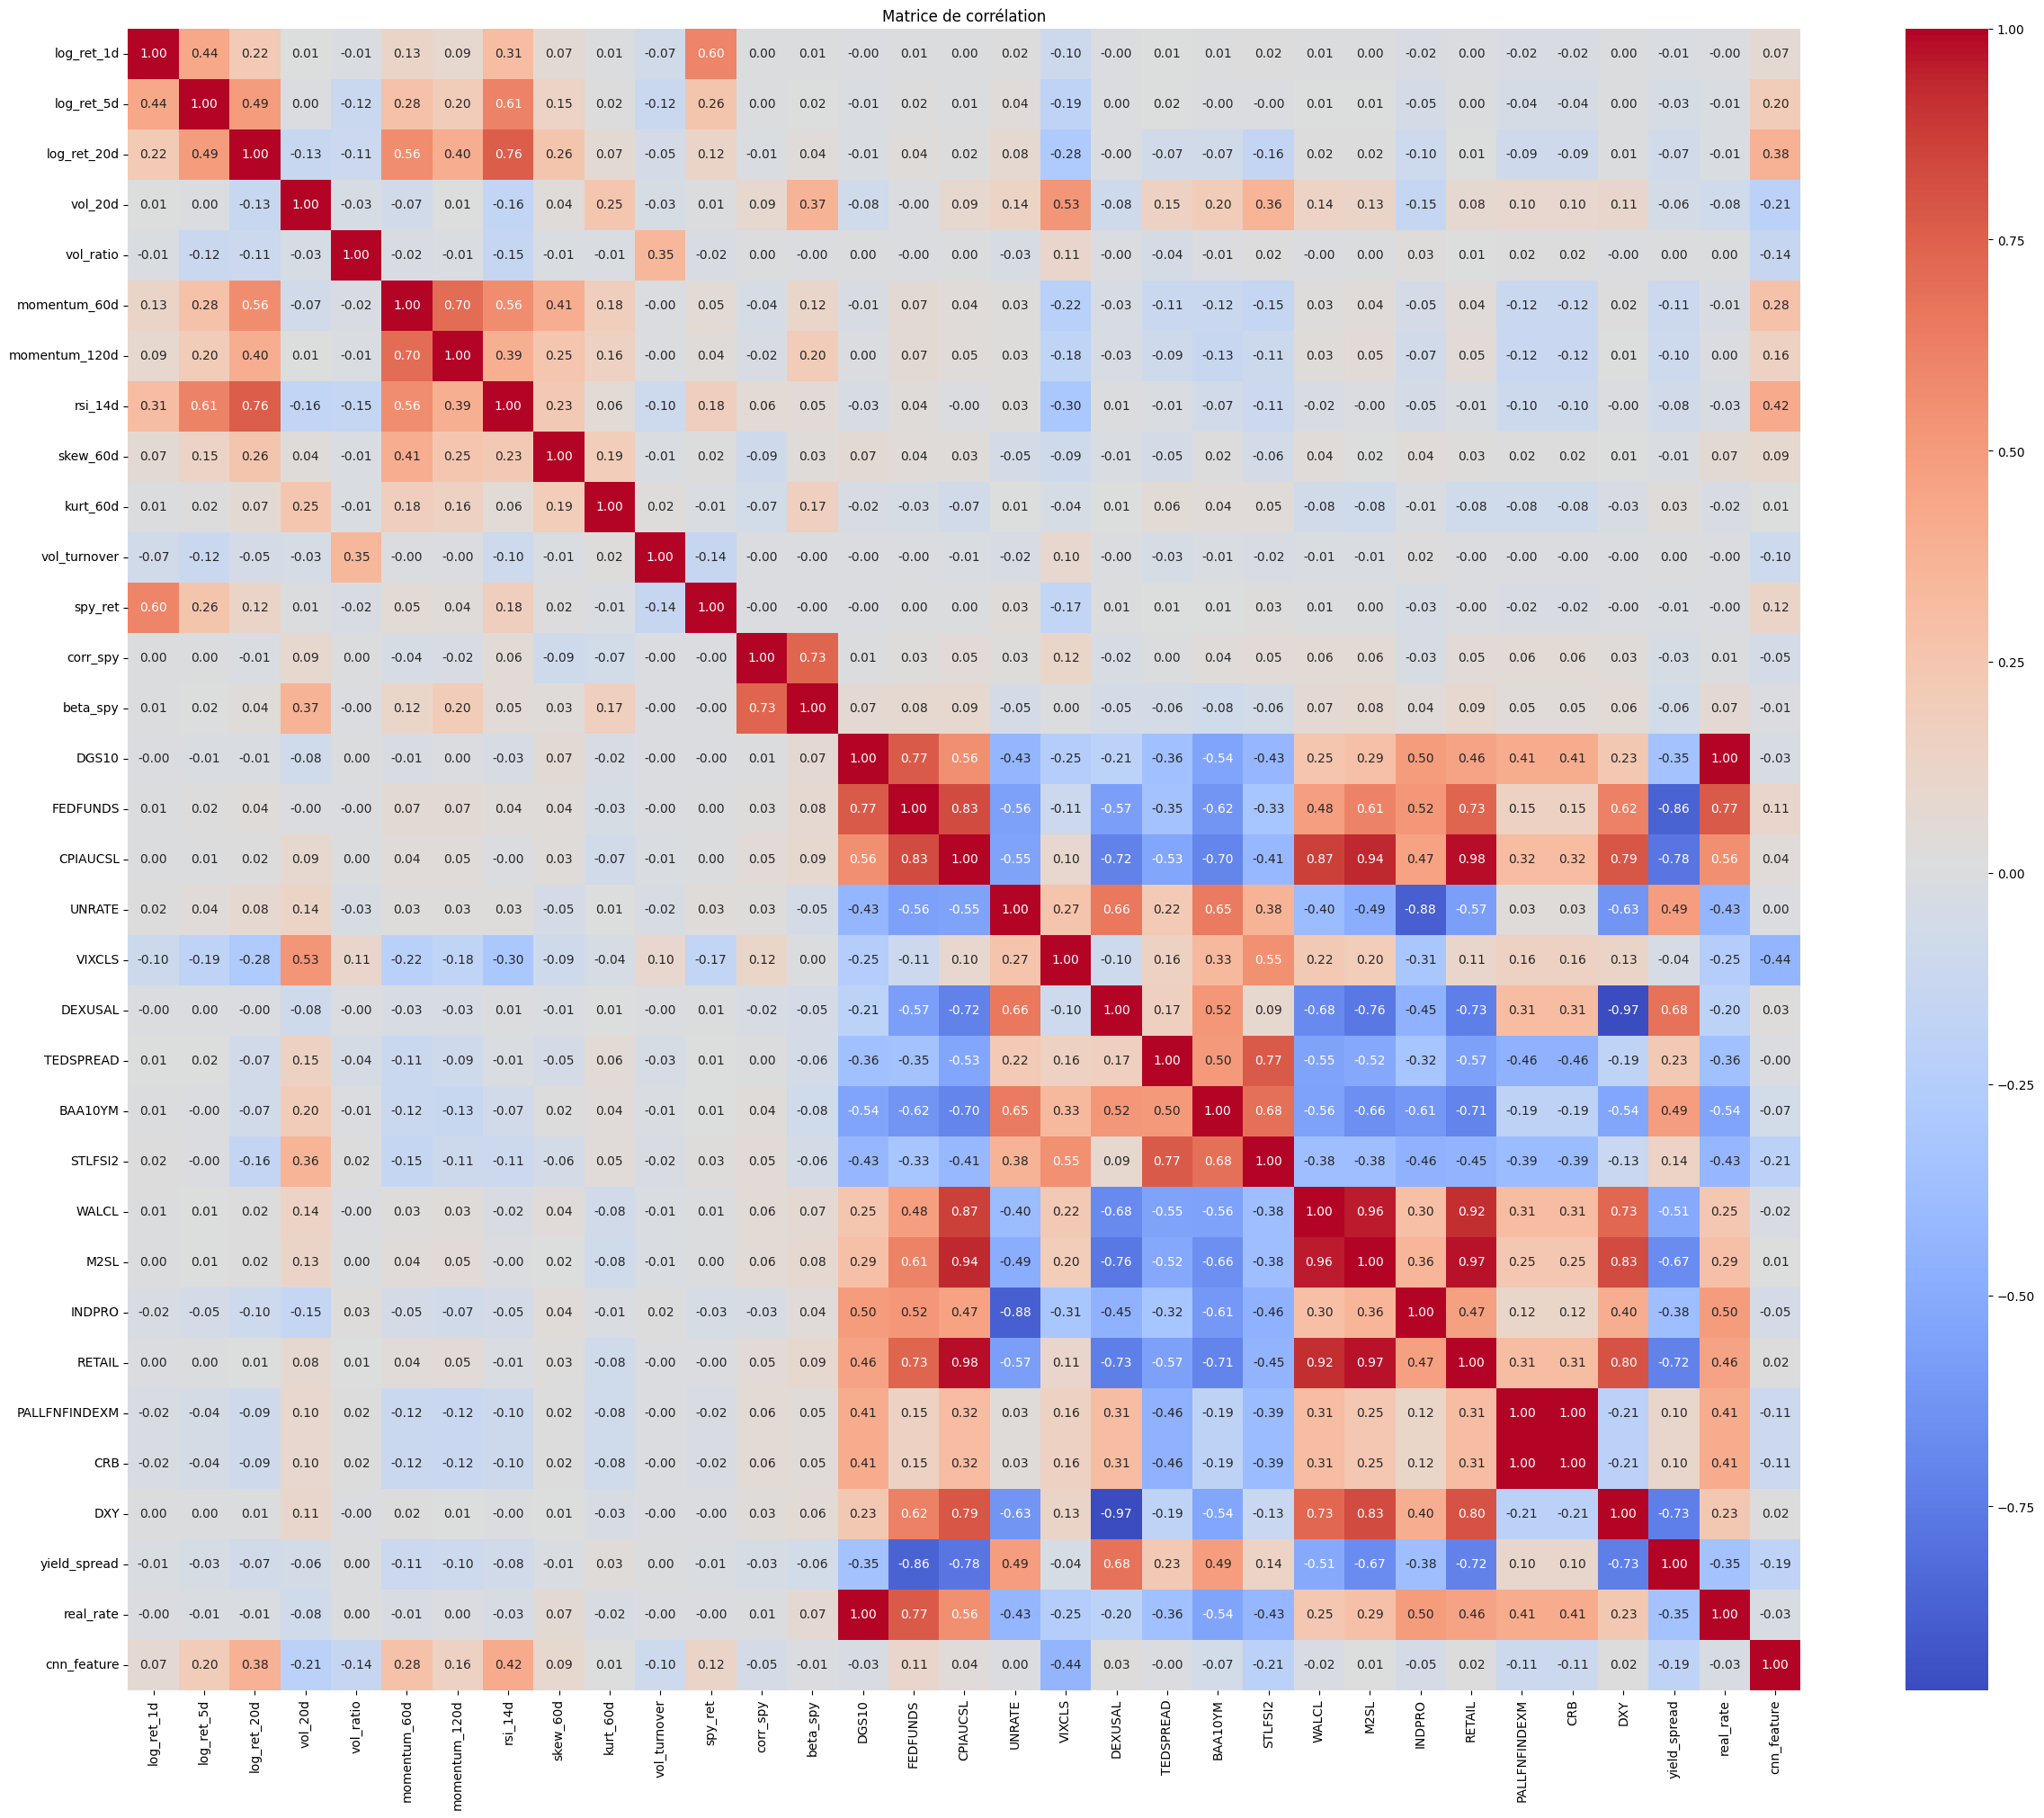

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df_no_nan = df.dropna(axis = 0)
print(df_no_nan)
df_no_nan.drop(columns=["Unnamed: 0","ticker","Date"],inplace=True)
print(df_no_nan)
corr = df_no_nan.corr()
print(corr)
plt.figure(figsize=(30, 24))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.savefig("correlation_matrix.png")
plt.show()

plt.figure(figsize=(30, 24))
sns.clustermap(corr, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation clustermap")
plt.savefig("correlation_matrix_clustermap.png")
plt.show()



In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ========= 1. Préparation des données =========
scaler = StandardScaler()
X = scaler.fit_transform(df_no_nan.values)
X_tensor = torch.tensor(X, dtype=torch.float32)

device = torch.device("cpu")

# ========= 2. Paramètres =========
batch_size = 256   # ajuste selon ta RAM
epochs = 100
input_dim = df_no_nan.shape[1]

# ========= 3. DataLoader manuel =========
def batch_iter(tensor, batch_size):
    n = tensor.shape[0]
    for i in range(0, n, batch_size):
        yield tensor[i:i+batch_size].unsqueeze(0)  # (1, seq_len, features)

# ========= 4. Modèle Transformer léger =========
class TransformerEncoderModel(nn.Module):
    def __init__(self, input_dim, d_model=32, nhead=2, num_layers=1, dim_feedforward=64):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=0.1,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(d_model, input_dim)

    def forward(self, x):
        x = self.input_layer(x)
        encoded = self.encoder(x)
        out = self.output_layer(encoded)
        return out, encoded

model = TransformerEncoderModel(input_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# ========= 5. Entraînement par batch =========
for epoch in range(epochs):
    total_loss = 0
    for batch in batch_iter(X_tensor, batch_size):
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, encoded = model(batch)
        loss = loss_fn(recon, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {total_loss:.6f}")

# ========= 6. Extraction des embeddings =========
encoded_list = []
with torch.no_grad():
    for batch in batch_iter(X_tensor, batch_size):
        _, encoded = model(batch.to(device))
        encoded_list.append(encoded.squeeze(0).cpu().numpy())


Epoch 000 | Loss: 122.475482
Epoch 010 | Loss: 6.615999
Epoch 020 | Loss: 3.149944
Epoch 030 | Loss: 1.820700
Epoch 040 | Loss: 1.131200
Epoch 050 | Loss: 2.162003
Epoch 060 | Loss: 1.115502
Epoch 070 | Loss: 1.361788
Epoch 080 | Loss: 2.405551
Epoch 090 | Loss: 0.713695


ValueError: Shape of passed values is (59526, 32), indices imply (61638, 32)

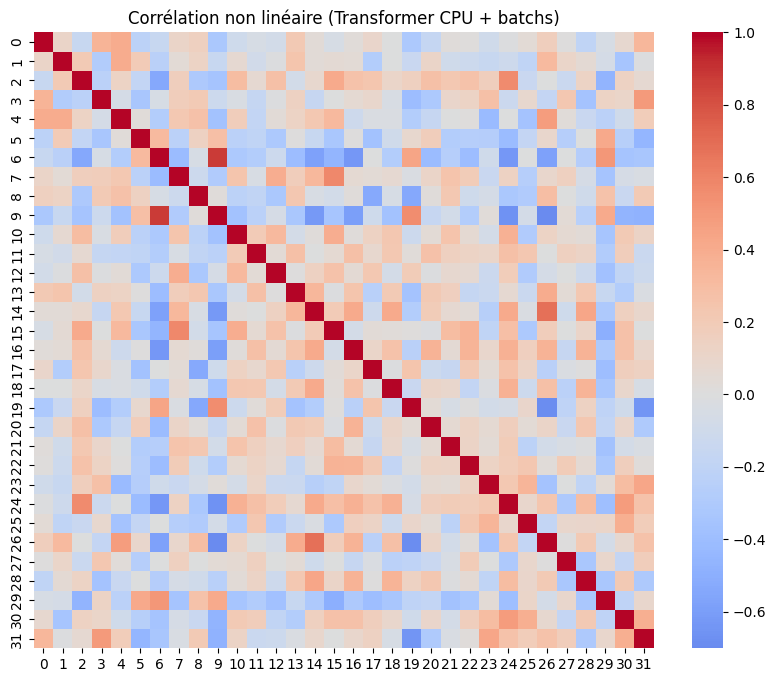

In [11]:

latent = np.vstack(encoded_list)
latent_df = pd.DataFrame(latent, index=df_no_nan.index)

# ========= 7. Corrélation dans l’espace latent =========
corr_latent = latent_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_latent, cmap='coolwarm', center=0)
plt.title("Corrélation non linéaire (Transformer CPU + batchs)")
plt.show()


C:\Users\romai\AppData\Local\Temp\ipykernel_33996\152237167.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start="2006-01-01", end="2025-09-01", progress=False)[["Close"]]


Price            Close
Ticker            AAPL
Date                  
2006-01-03    2.241830
2006-01-04    2.248429
2006-01-05    2.230734
2006-01-06    2.288316
2006-01-09    2.280818
...                ...
2025-08-25  226.940002
2025-08-26  229.087921
2025-08-27  230.266785
2025-08-28  232.334778
2025-08-29  231.915176

[4946 rows x 1 columns]
[  2.24183011   2.24842906   2.23073387 ... 230.26678467 232.33477783
 231.91517639]
[  2.24183011   2.24842906   2.23073387 ... 168.51391602 168.81793213
 166.80751038]


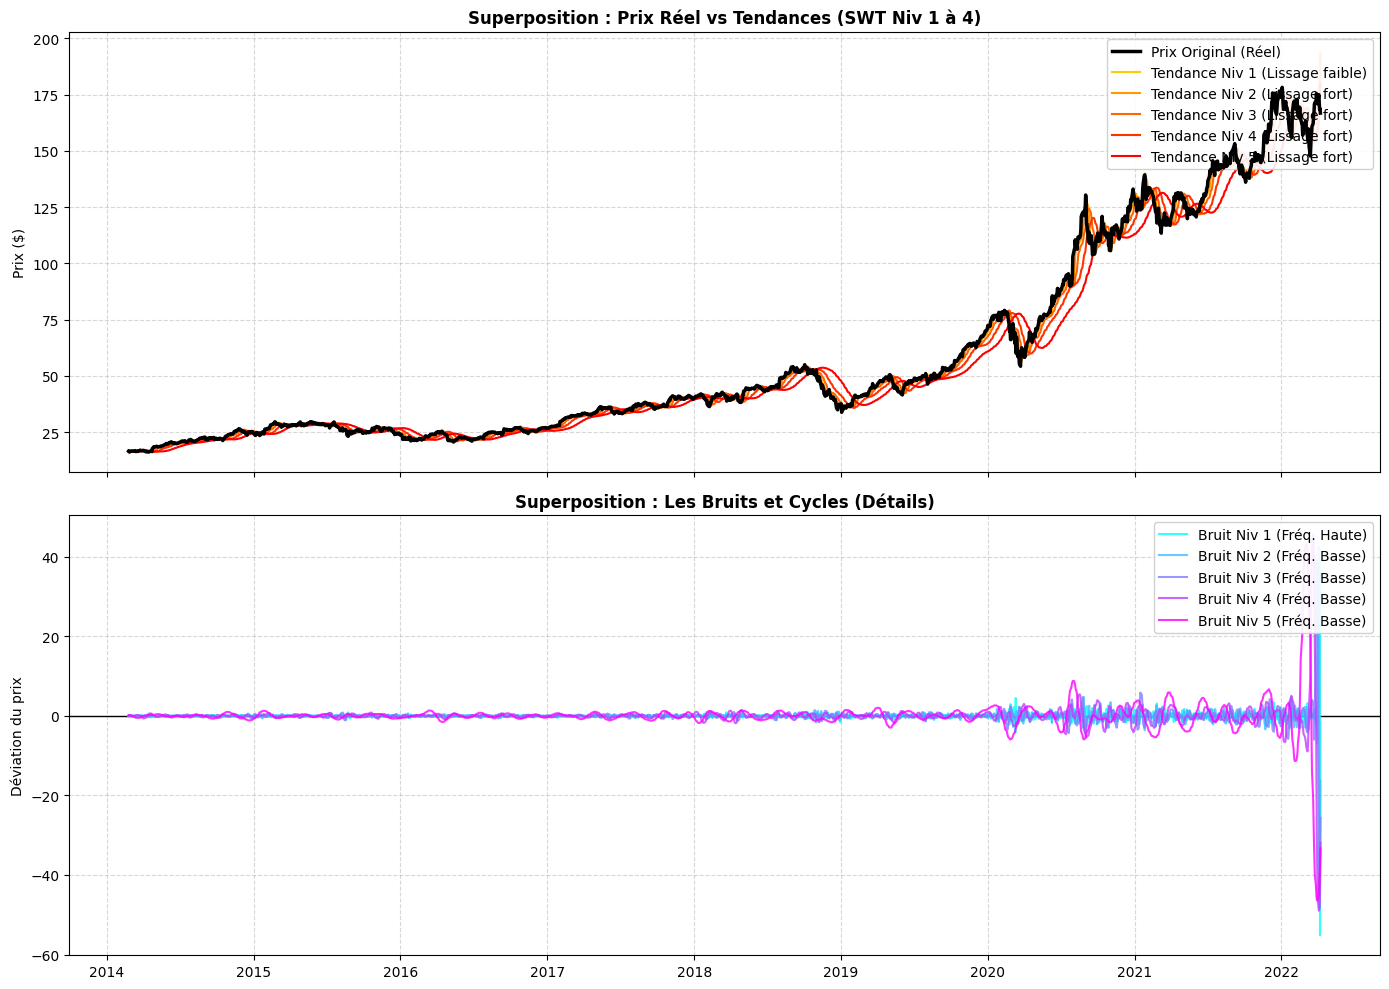

In [21]:
import pywt
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.cm as cm # Pour les dégradés de couleurs

# --- 1. Préparation des données ---
t = "AAPL"
df = yf.download(t, start="2006-01-01", end="2025-09-01", progress=False)[["Close"]]
print(df)
prix = df["Close"].values.flatten().astype(float)
print(prix)
# On garde une puissance de 2 pour la propreté (ex: 64 jours), 
# mais la SWT marche techniquement sur n'importe quelle longueur.
windows = 2048
prix = prix[:2*windows]
print(prix)
dates = df.index[:2*windows]

# --- 2. Calcul SWT ---
n_levels = 5
wavelet = 'db3'
# On récupère les coefficients : liste de tuples [(cA4, cD4), ..., (cA1, cD1)]
coeffs = pywt.swt(prix, wavelet=wavelet, level=n_levels, norm=True)

# On inverse pour avoir l'ordre intuitif : Niveau 1 (Rapide) -> Niveau 4 (Lent)
coeffs_sorted = coeffs[::-1] 

# --- 3. Affichage Superposé ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- GRAPHE 1 : PRIX + TENDANCES (Approximations) ---
# On trace le prix original en gros et noir
ax1.plot(dates[-windows:], prix[-windows:], color='black', linewidth=2.5, label='Prix Original (Réel)', zorder=10)

# On boucle pour afficher les tendances (Approximations cA)
# On utilise une colormap "Autumn" (Jaune -> Rouge) pour distinguer la profondeur
colors_trend = cm.autumn_r(np.linspace(0.2, 1, n_levels))

for i, (cA, cD) in enumerate(coeffs_sorted):
    level = i + 1
    # Plus le niveau est élevé, plus le trait est épais pour symboliser la force de la tendance
    ax1.plot(dates[-windows:], cA[-windows:], color=colors_trend[i], linewidth=1.5, 
             label=f'Tendance Niv {level} (Lissage {"faible" if level==1 else "fort"})')

ax1.set_title("Superposition : Prix Réel vs Tendances (SWT Niv 1 à 4)", fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_ylabel("Prix ($)")

# --- GRAPHE 2 : BRUITS (Détails) ---
# On trace une ligne à 0 pour référence
ax2.axhline(0, color='black', linewidth=1, linestyle='-')

# On utilise une colormap "Cool" (Cyan -> Violet) pour les bruits
colors_detail = cm.cool(np.linspace(0, 1, n_levels))

for i, (cA, cD) in enumerate(coeffs_sorted):
    level = i + 1
    ax2.plot(dates[-windows:], cD[-windows:], color=colors_detail[i], linewidth=1.5, alpha=0.8,
             label=f'Bruit Niv {level} (Fréq. {"Haute" if level==1 else "Basse"})')

ax2.set_title("Superposition : Les Bruits et Cycles (Détails)", fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', framealpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylabel("Déviation du prix")

plt.tight_layout()
plt.show()

C:\Users\romai\AppData\Local\Temp\ipykernel_34472\1606082611.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start, end=end, progress=False)[["Close"]]


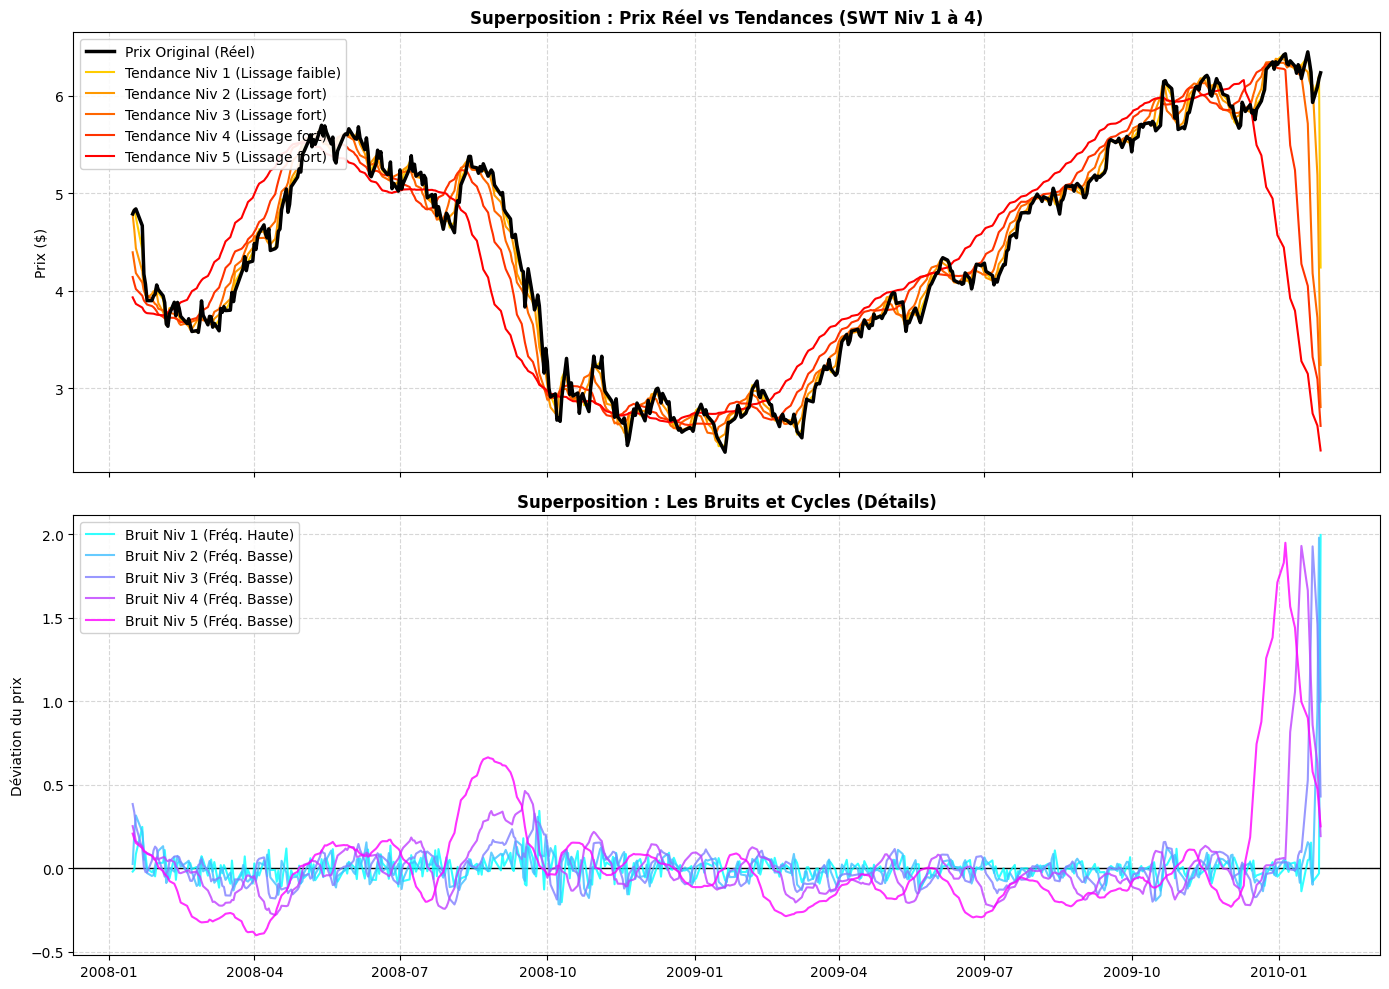

C:\Users\romai\AppData\Local\Temp\ipykernel_34472\1606082611.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start, end=end, progress=False)[["Close"]]


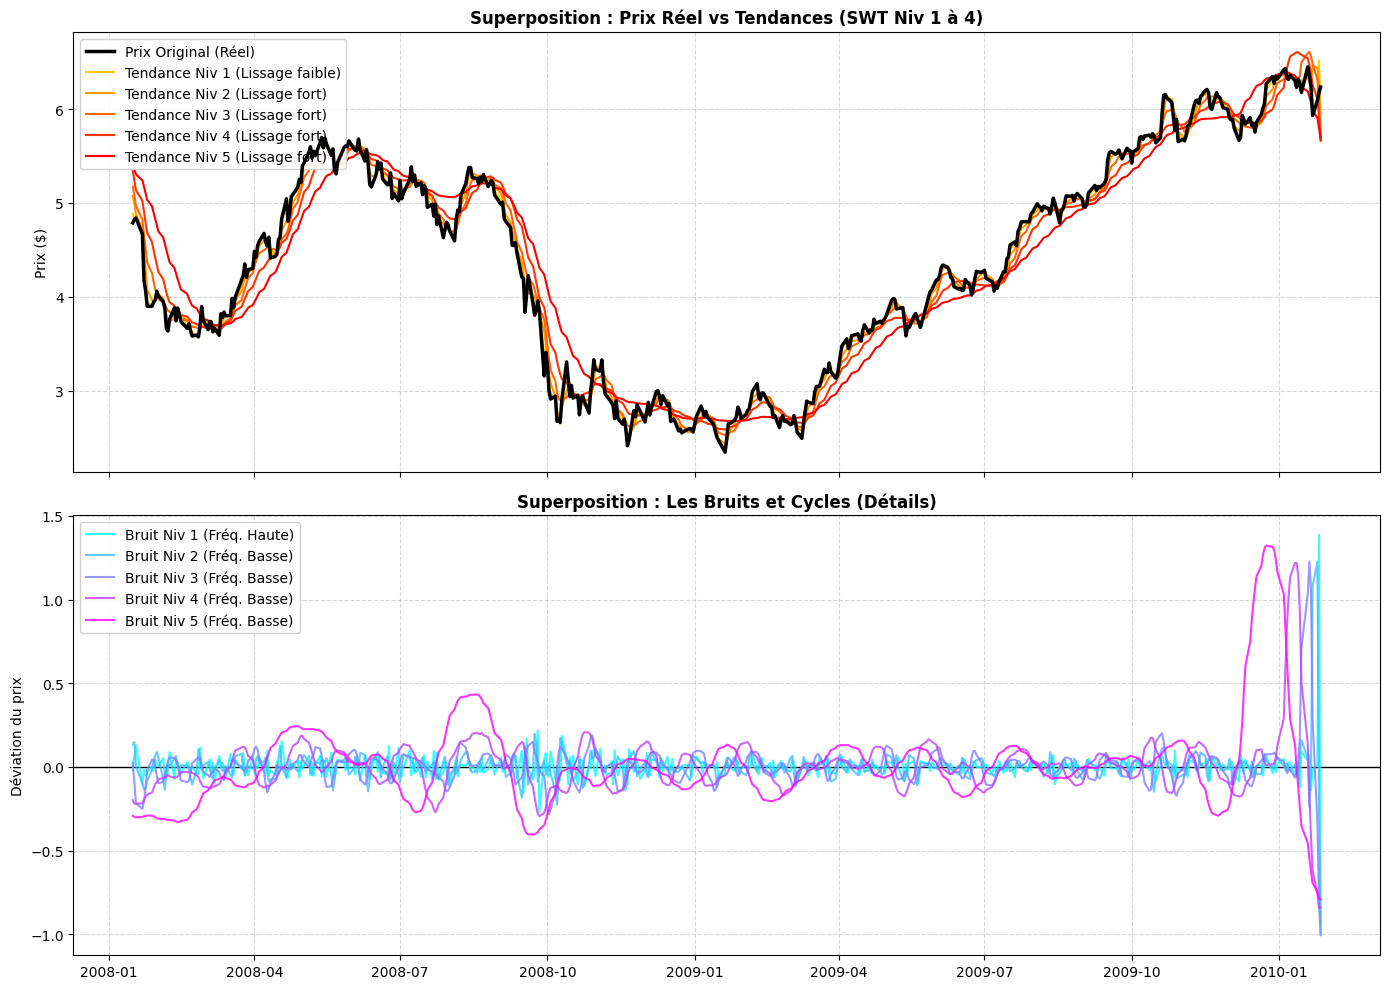

C:\Users\romai\AppData\Local\Temp\ipykernel_34472\1606082611.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start, end=end, progress=False)[["Close"]]


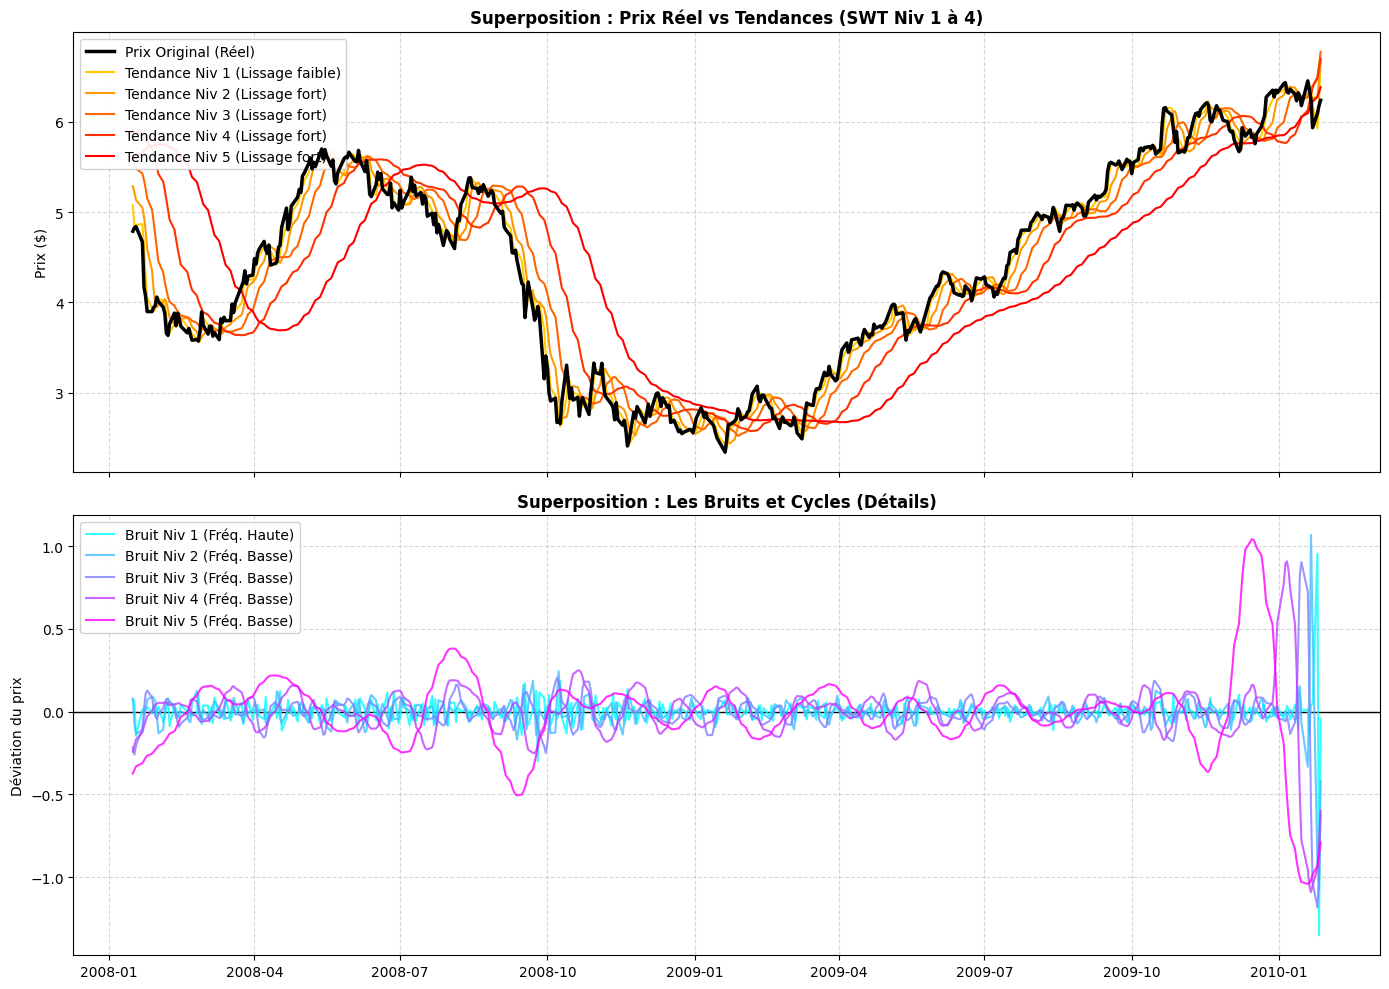

C:\Users\romai\AppData\Local\Temp\ipykernel_34472\1606082611.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start, end=end, progress=False)[["Close"]]


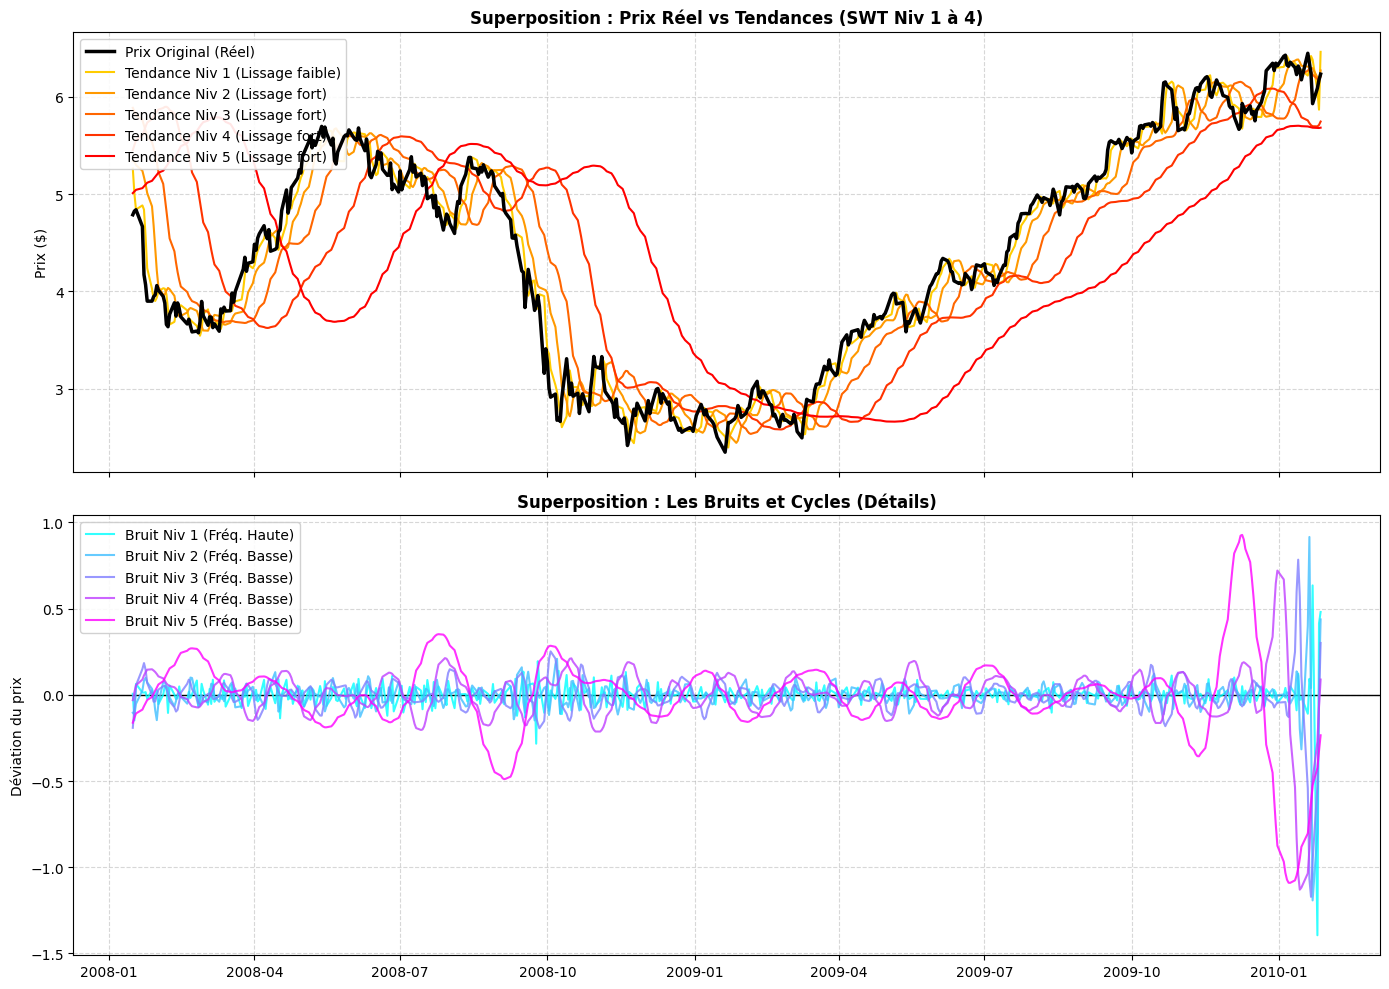

In [5]:
import pywt
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.cm as cm # Pour les dégradés de couleurs

def make_feature(n_levels = 2,wave = "db1", plot=False,windows=2048,start="2006-01-01",end="2025-09-01"):


    # --- 1. Préparation des données ---
    t = "AAPL"
    df = yf.download(t, start=start, end=end, progress=False)[["Close"]]
    prix = df["Close"].values.flatten().astype(float)
    # On garde une puissance de 2 pour la propreté (ex: 64 jours), 
    # mais la SWT marche techniquement sur n'importe quelle longueur.
    prix = prix[:2*windows]
    dates = df.index[:2*windows]

    # --- 2. Calcul SWT ---
    # On récupère les coefficients : liste de tuples [(cA4, cD4), ..., (cA1, cD1)]
    coeffs = pywt.swt(prix, wavelet=wave, level=n_levels, norm=True)

    # On inverse pour avoir l'ordre intuitif : Niveau 1 (Rapide) -> Niveau 4 (Lent)
    coeffs_sorted = coeffs[::-1] 

    if plot:
        # --- 3. Affichage Superposé ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        # --- GRAPHE 1 : PRIX + TENDANCES (Approximations) ---
        # On trace le prix original en gros et noir
        ax1.plot(dates[-windows:], prix[-windows:], color='black', linewidth=2.5, label='Prix Original (Réel)', zorder=10)

        # On boucle pour afficher les tendances (Approximations cA)
        # On utilise une colormap "Autumn" (Jaune -> Rouge) pour distinguer la profondeur
        colors_trend = cm.autumn_r(np.linspace(0.2, 1, n_levels))

        for i, (cA, cD) in enumerate(coeffs_sorted):
            level_i = i + 1
            # Plus le niveau est élevé, plus le trait est épais pour symboliser la force de la tendance
            ax1.plot(dates[-windows:], cA[-windows:], color=colors_trend[i], linewidth=1.5, 
                     label=f'Tendance Niv {level_i} (Lissage {"faible" if level_i==1 else "fort"})')
        ax1.set_title("Superposition : Prix Réel vs Tendances (SWT Niv 1 à 4)", fontsize=12, fontweight='bold')
        ax1.legend(loc='upper left', framealpha=0.9)  
        ax1.grid(True, linestyle='--', alpha=0.5)
        ax1.set_ylabel("Prix ($)")
        # --- GRAPHE 2 : BRUITS (Détails) ---
        # On trace une ligne à 0 pour référence 
        ax2.axhline(0, color='black', linewidth=1, linestyle='-')
        # On utilise une colormap "Cool" (Cyan -> Violet) pour les bruits
        colors_detail = cm.cool(np.linspace(0, 1, n_levels))
        for i, (cA, cD) in enumerate(coeffs_sorted):
            level_i = i + 1
            ax2.plot(dates[-windows:], cD[-windows:], color=colors_detail[i], linewidth=1.5, alpha=0.8,
                     label=f'Bruit Niv {level_i} (Fréq. {"Haute" if level_i==1 else "Basse"})')
        ax2.set_title("Superposition : Les Bruits et Cycles (Détails)", fontsize=12, fontweight='bold')
        ax2.legend(loc='upper left', framealpha=0.9)
        ax2.grid(True, linestyle='--', alpha=0.5)
        ax2.set_ylabel("Déviation du prix")
        plt.tight_layout()
        plt.show()
    # On retourne la feature demandée
    cA, cD = coeffs_sorted[n_levels - 1]
    return cA, cD
cA,cD = make_feature(n_levels=5,wave="db1", plot=True,windows=512)
cA,cD = make_feature(n_levels=5,wave="db2", plot=True,windows=512)
cA,cD = make_feature(n_levels=5,wave="db3", plot=True,windows=512)
cA,cD = make_feature(n_levels=5,wave="db4", plot=True,windows=512)

C:\Users\romai\AppData\Local\Temp\ipykernel_34472\2666636449.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start, end=end, progress=False)[["Close"]]


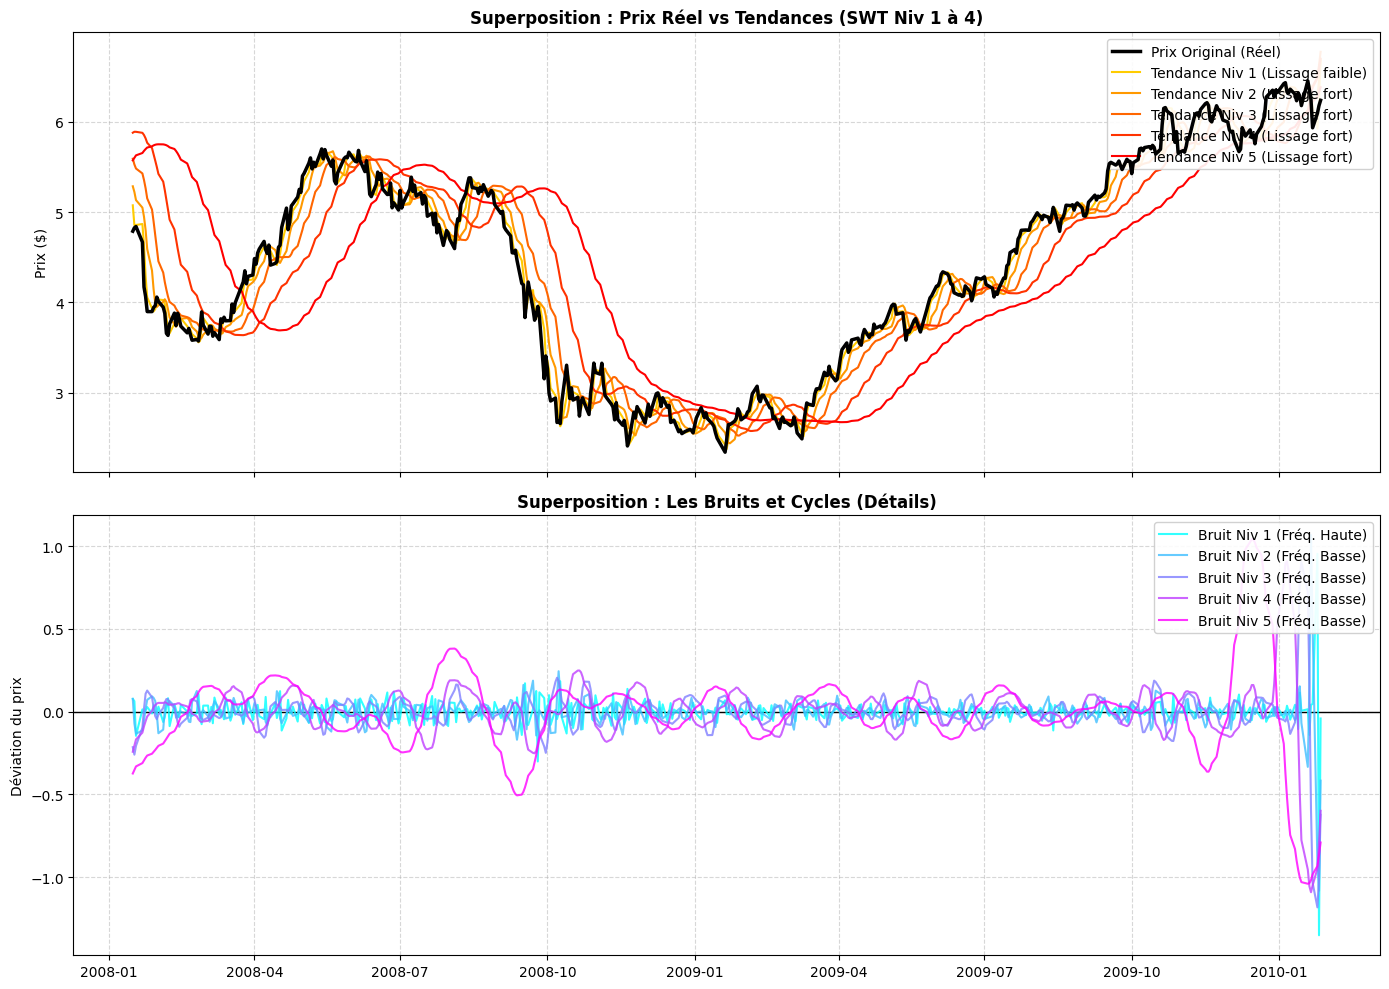

In [3]:
cA,cD = make_feature(n_levels=5,wave="db3", plot=True,windows=512,start="2006-01-01")